In [1]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import pickle

velocity = 1.0
num_epochs = 10000

In [ ]:
def analytical_solution(t, x):
    u = 0.5 * (torch.sin(torch.pi * (x + t)) + torch.sin(torch.pi * (x - t)))
    v = 0.5 * torch.pi * (torch.cos(torch.pi * (x + t)) - torch.cos(torch.pi * (x - t)))
    return torch.cat([u, v], dim=1)

class PINN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(PINN, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 2) 
        self.tanh = nn.Tanh()

    def forward(self, x, t=None):
        if t is not None:
            inputs = torch.cat([t, x], dim=1) 
        else:
            inputs = x
            
        out = self.linear1(inputs)
        out = self.tanh(out)
        out = self.linear2(out)
        out = self.tanh(out)
        out = self.linear3(out)
        out = self.tanh(out)
        out = self.linear4(out)
        out = self.tanh(out)
        out = self.output(out)
        return out

In [3]:
def x_f_loss_fun(inputs, model):
    """
    计算PDE残差，使用u_t=v和v_t=c^2*u_xx形式
    """
    if not inputs.requires_grad:
        inputs = Variable(inputs, requires_grad=True)

    uv = model(inputs)
    u = uv[:, 0:1]  
    v = uv[:, 1:2]  

    u_grad = torch.autograd.grad(u, inputs, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = u_grad[:, 0:1] 
    u_x = u_grad[:, 1:2]  

    v_grad = torch.autograd.grad(v, inputs, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_t = v_grad[:, 0:1]  

    u_xx = torch.autograd.grad(u_x, inputs, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 1:2]

    f_u = u_t - v       
    f_v = v_t - velocity**2 * u_xx  
    
    return f_u, f_v

In [4]:
def boundary_loss(model, x_bc):
    outputs = model(x_bc)
    u = outputs[:, 0:1] 
    return torch.mean(u**2)

def initial_condition_loss(model, x_ic):
    outputs = model(x_ic)
    u = outputs[:, 0:1]
    v = outputs[:, 1:2]

    x = x_ic[:, 1:2]

    u_ic_target = torch.sin(torch.pi * x)
    v_ic_target = torch.zeros_like(v)  
    
    u_loss = torch.mean((u - u_ic_target)**2)
    v_loss = torch.mean((v - v_ic_target)**2)
    
    return u_loss + v_loss

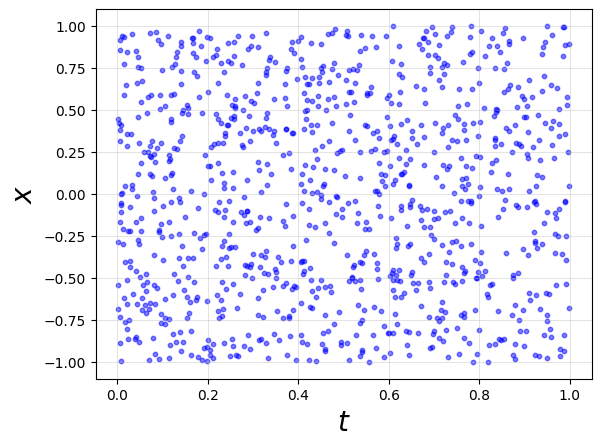

In [5]:
lb = [0.0, -1.0]  
ub = [1.0, 1.0]   

N_colloc = 1000
t_colloc = torch.rand(N_colloc, 1) * (ub[0] - lb[0]) + lb[0] 
x_colloc = torch.rand(N_colloc, 1) * (ub[1] - lb[1]) + lb[1] 
x_colloc_combined = torch.cat([t_colloc, x_colloc], dim=1)
x_colloc_combined.requires_grad_(True)

N_bc = 100
t_bc = torch.rand(N_bc, 1) * (ub[0] - lb[0]) + lb[0]  
x_bc_left = -torch.ones(N_bc//2, 1) 
x_bc_right = torch.ones(N_bc//2, 1)
x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)
t_bc_split = torch.split(t_bc, N_bc//2)
x_bc_left_combined = torch.cat([t_bc_split[0], x_bc_left], dim=1)
x_bc_right_combined = torch.cat([t_bc_split[1], x_bc_right], dim=1)
x_bc_combined = torch.cat([x_bc_left_combined, x_bc_right_combined], dim=0)
x_bc_combined.requires_grad_(True)

N_ic = 100
x_ic = torch.rand(N_ic, 1) * 2 - 1  
t_ic = torch.zeros(N_ic, 1)
x_ic_combined = torch.cat([t_ic, x_ic], dim=1)
x_ic_combined.requires_grad_(True)

plt.scatter(t_colloc.detach().numpy(), x_colloc.detach().numpy(), color='blue', alpha=0.5, s=10)
plt.xlabel('$t$', fontsize=20)
plt.ylabel('$x$', fontsize=20)
plt.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
plt.show()

In [6]:
# Create model and optimizer
model = PINN(2, 50)  
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)

for epoch in range(num_epochs):
    optimizer.zero_grad()

    f_u, f_v = x_f_loss_fun(x_colloc_combined, model)
    loss_pde = torch.mean(f_u**2) + torch.mean(f_v**2)

    loss_bc = boundary_loss(model, x_bc_combined)

    loss_ic = initial_condition_loss(model, x_ic_combined)

    total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
    
    total_loss.backward()
    optimizer.step()
    scheduler.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}/{num_epochs}, "
              f"Loss: {total_loss.item():.6f}, "
              f"PDE: {loss_pde.item():.6f}, "
              f"BC: {loss_bc.item():.6f}, "
              f"IC: {loss_ic.item():.6f}")

Epoch: 0/10000, Loss: 5.305126, PDE: 0.019468, BC: 0.019391, IC: 0.509175
Epoch: 1000/10000, Loss: 0.110717, PDE: 0.046011, BC: 0.003626, IC: 0.002844
Epoch: 2000/10000, Loss: 0.043914, PDE: 0.023233, BC: 0.001201, IC: 0.000867
Epoch: 3000/10000, Loss: 0.031153, PDE: 0.018591, BC: 0.000724, IC: 0.000532
Epoch: 4000/10000, Loss: 0.027284, PDE: 0.016974, BC: 0.000592, IC: 0.000439
Epoch: 5000/10000, Loss: 0.025894, PDE: 0.016358, BC: 0.000547, IC: 0.000407
Epoch: 6000/10000, Loss: 0.025375, PDE: 0.016123, BC: 0.000530, IC: 0.000395
Epoch: 7000/10000, Loss: 0.025186, PDE: 0.016035, BC: 0.000525, IC: 0.000390
Epoch: 8000/10000, Loss: 0.025120, PDE: 0.016006, BC: 0.000522, IC: 0.000389
Epoch: 9000/10000, Loss: 0.025103, PDE: 0.015998, BC: 0.000522, IC: 0.000389


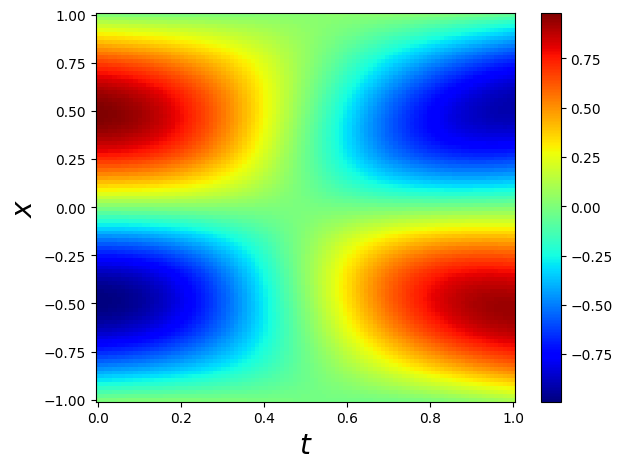

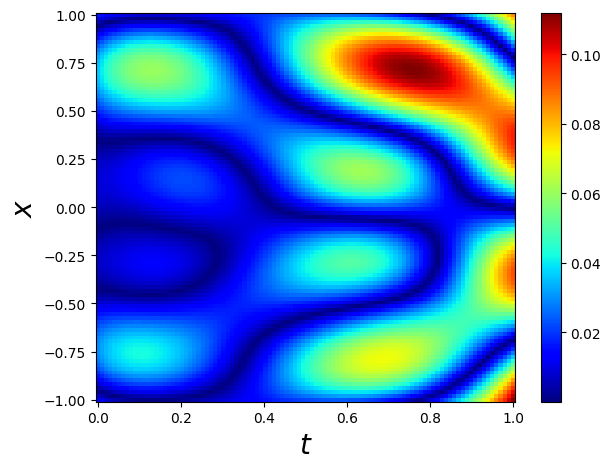

总体u的L2误差: 0.039773


In [7]:
nx, nt = 100, 100
x = torch.linspace(-1, 1, nx).reshape(-1, 1)
t = torch.linspace(0, 1, nt).reshape(-1, 1)

X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing='ij')

X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

X_test = torch.cat([T_flat, X_flat], dim=1)

with torch.no_grad():
    uv_pred = model(X_test)

u_pred = uv_pred[:, 0].reshape(nx, nt).detach().numpy()
v_pred = uv_pred[:, 1].reshape(nx, nt).detach().numpy()

uv_exact = analytical_solution(T_flat, X_flat)
u_exact = uv_exact[:, 0].reshape(nx, nt).detach().numpy()
v_exact = uv_exact[:, 1].reshape(nx, nt).detach().numpy()

u_error = np.abs(u_pred - u_exact)
v_error = np.abs(v_pred - v_exact)


# plot
plt.figure()
im = plt.pcolormesh(T.numpy(), X.numpy(), u_pred, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('$t$', fontsize=20)
plt.ylabel('$x$', fontsize=20)
plt.tight_layout()
plt.show()

plt.figure()
im = plt.pcolormesh(T.numpy(), X.numpy(), u_error, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('$t$', fontsize=20)
plt.ylabel('$x$', fontsize=20)
plt.tight_layout()
plt.show()


total_u_l2_error = np.sqrt(np.mean(np.square(u_pred - u_exact)))
print(f"总体u的L2误差: {total_u_l2_error:.6f}")